<a href="https://colab.research.google.com/github/SarthakSaxena12/CCC-DAY1/blob/main/CREDIT_CARD_MODEL_TRAINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.shape

(284807, 31)

In [6]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


There are no nulls in the dataset

In [7]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


In [8]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [9]:
df.duplicated().sum()

np.int64(1081)

There are about 1081 duplicated columns in the dataset

In [10]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


This confirms that they are real duplicates, same transactions having multiple entries in the dataset

In [11]:
print(df[df.duplicated()]['Class'].value_counts())

Class
0    1062
1      19
Name: count, dtype: int64


So, in those duplicates, there are 19 class 1 duplicates, so we would lose some of those fraud cases, which were already very imbalanced. But it was important dropping them to prevent data leakage at the time of train test split.

In [12]:
df = df.drop_duplicates()
print(df['Class'].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


## EDA

Text(0.5, 1.0, 'Class Distribution')

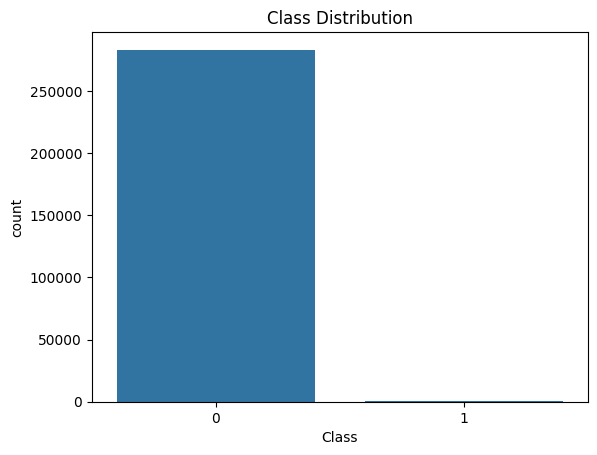

In [13]:
sns.countplot(data=df, x='Class')
plt.title('Class Distribution')

This shows the huge imbalance of this dataset, with majority(99% +) transactions under not fraud and only 473 are the fraud ones

Text(0, 0.5, 'Count')

/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


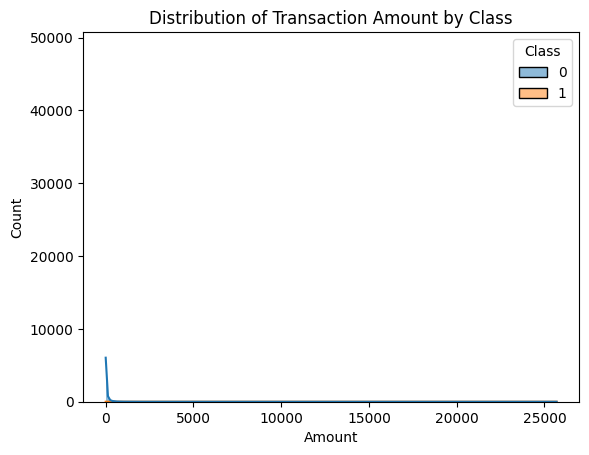

In [14]:
sns.histplot(data=df, x='Amount', hue='Class', kde=True)
plt.title('Distribution of Transaction Amount by Class')
plt.xlabel('Amount')
plt.ylabel('Count')

#### Standard Amount Distribution Plot Fails

The raw transaction amount distribution plotted above is visually unreadable due to two severe scaling issues:

* Extreme Right Skew (X-Axis): The vast majority of transactions are relatively small (75% are under €77), but the dataset contains massive outliers (up to €25000). Because a standard plot uses a linear scale, the x-axis stretches all the way to 25,000 to fit a single outlier, forcing 99% of the data into a single, massive spike at the left edge.
* Severe Class Imbalance (Y-Axis): Because the plot displays raw counts, the y-axis scales up to 50,000+ to accommodate the 283,000+ legitimate transactions (Class 0). At this massive scale, the 473 fraud transactions (Class 1) are visually crushed and completely invisible.

To fix this, we applied a log1p transform (log(1 + Amount)) to compress
the tail and reveal the underlying shape. We also normalized each class
independently (stat='density', common_norm=False) rather than jointly,
since fraud cases make up less than 0.2% of transactions without this,
the fraud distribution would still be flattened by sheer volume of legitimate
transactions.

Conclusion: We cannot analyze the relationship between transaction amount and fraud using a standard linear scale and raw counts. A log transformation and density scaling are required to make the underlying distributions visible.

Text(0, 0.5, 'Density')

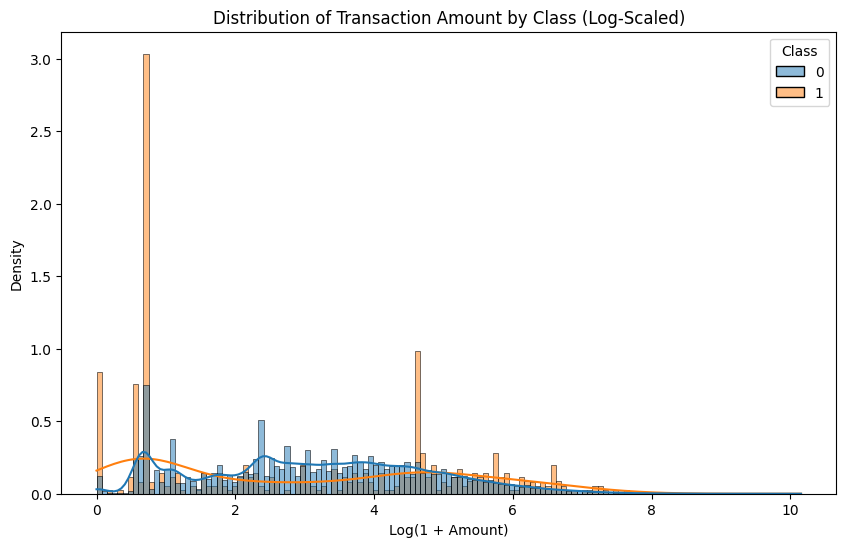

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(x=np.log1p(df['Amount']), hue=df['Class'], stat='density', common_norm=False, kde=True)
plt.title('Distribution of Transaction Amount by Class (Log-Scaled)')
plt.xlabel('Log(1 + Amount)')
plt.ylabel('Density')

The log-scaled transaction amount distribution reveals that genuine transactions (Class 0) follow a relatively smooth, normal distribution, whereas fraudulent transactions (Class 1) are highly inconsistent and heavily clustered toward smaller values. Most notably, there is a massive spike in fraudulent activity at exactly zero, indicating that fraudsters frequently use €0 authorizations to test if a stolen card is active before attempting larger purchases. Because the spending patterns between the two classes differ so significantly, the transaction amount will serve as a highly predictive feature for the model.

Text(0, 0.5, 'Count')

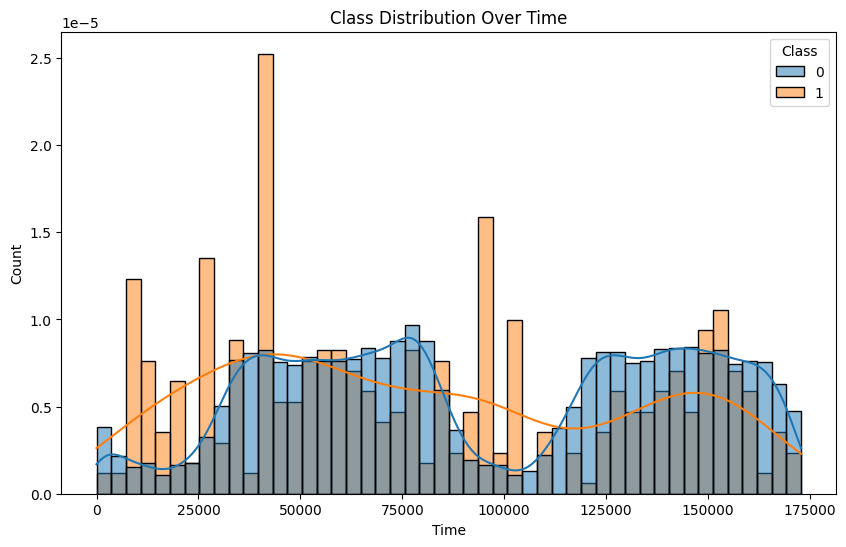

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Time', hue='Class',stat='density', common_norm=False, bins=48, kde=True)
plt.title('Class Distribution Over Time')
plt.xlabel('Time')
plt.ylabel('Count')

The transaction time distribution reveals that legitimate transactions follow a clear day/night cycle, dipping significantly during nighttime hours. In contrast, fraudulent activities do not follow this schedule and operate continuously. As a result, fraud cases spike disproportionately during these off-hours when normal transaction volume is at its lowest, making the time of the transaction a strong predictive feature for identifying fraudulent behavior.

<Axes: >

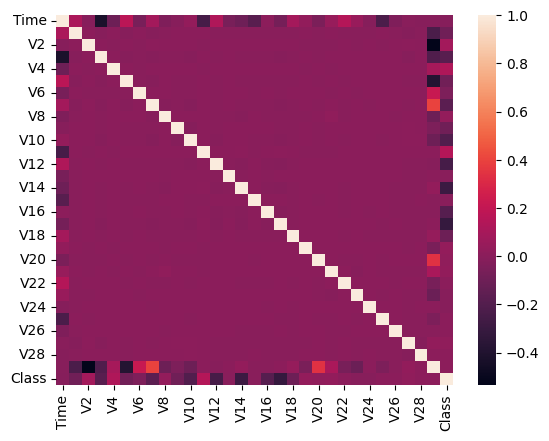

In [17]:
sns.heatmap(df.corr())